# LensLab · Data and comparable pairs
**Mohamed Bourega · Public Euclid Q1 data**

**Question:** Are the image neighbours of a known candidate more often other catalogued candidates than the neighbours of a comparable unlabelled object?

A foreground galaxy can bend light from a more distant source into arcs or multiple images. We use published candidate grades to study image neighbourhoods, without training a lens classifier. First, we inspect the data and give each retained candidate one comparable reference.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "src" / "lenslab").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
from lenslab import plots
from lenslab.selection_figures import run as selection_figures

candidates, regional_sample, gallery = plots.load_data(ROOT)
FIGURES = ROOT / "figures"
manifest = json.loads((ROOT / "data/manifest.json").read_text())

assert candidates.object_id.is_unique
assert regional_sample.object_id.is_unique
assert set(candidates.object_id).isdisjoint(regional_sample.object_id)

def show(figure, filename):
    plt.close(figure)
    display(Image(filename=str(FIGURES / filename)))

display(pd.DataFrame({
    "Objects": [len(candidates), len(regional_sample)],
    "Use": ["Candidate catalogue with expert grades", "Regional context before matching"],
}, index=["Discovery Engine", "Our regional Q1 sample"]))

,Objects,Use
Discovery Engine,2415,Candidate catalogue with expert grades
Our regional Q1 sample,10000,Regional context before matching


## 1 · Understand the labels

The [Discovery Engine catalogue](https://zenodo.org/records/15025832) provides expert visual grades **A, B and C**, with decreasing confidence. These are candidate grades, not a set of confirmed lenses and non-lenses. An object outside this catalogue is **unlabelled** for this analysis; it could still be a lens.

The descriptive reference sample contains 10,000 objects drawn without replacement from three fixed 0.6°-radius patches. It is neither the whole Euclid survey nor the source of the matched references used later.

In [2]:
display(candidates.grade.value_counts().reindex(list("ABC"))
        .rename_axis("Expert grade").to_frame("Published candidates"))
sampling = manifest["reference_sampling"]
print(f"Regional sampling frame: {sampling['frame_rows_after_excluding_candidates']:,} objects after excluding known candidates.")
print(f"Seeded regional sample: {len(regional_sample):,} objects, without replacement.")

Regional sampling frame: 68,813 objects after excluding known candidates.
Seeded regional sample: 10,000 objects, without replacement.


,Published candidates
Expert grade,
A,250
B,247
C,1918


## 2 · Check brightness and apparent size

These are the same quantities used to build the pairs: detection-total AB magnitude and segmentation area. Smaller magnitudes mean brighter objects; segmentation area counts image pixels assigned to an object. The regional sample already requires VIS detection, area ≥300 pixels and total AB <22.5.

Each histogram is normalized separately. Differences reflect the selection and sky coverage of these samples; they are not evidence that lensing causes a particular brightness or size. Non-positive or non-finite measurements are excluded from the displayed logarithms, while source tables are retained.

Out[3]: 2414


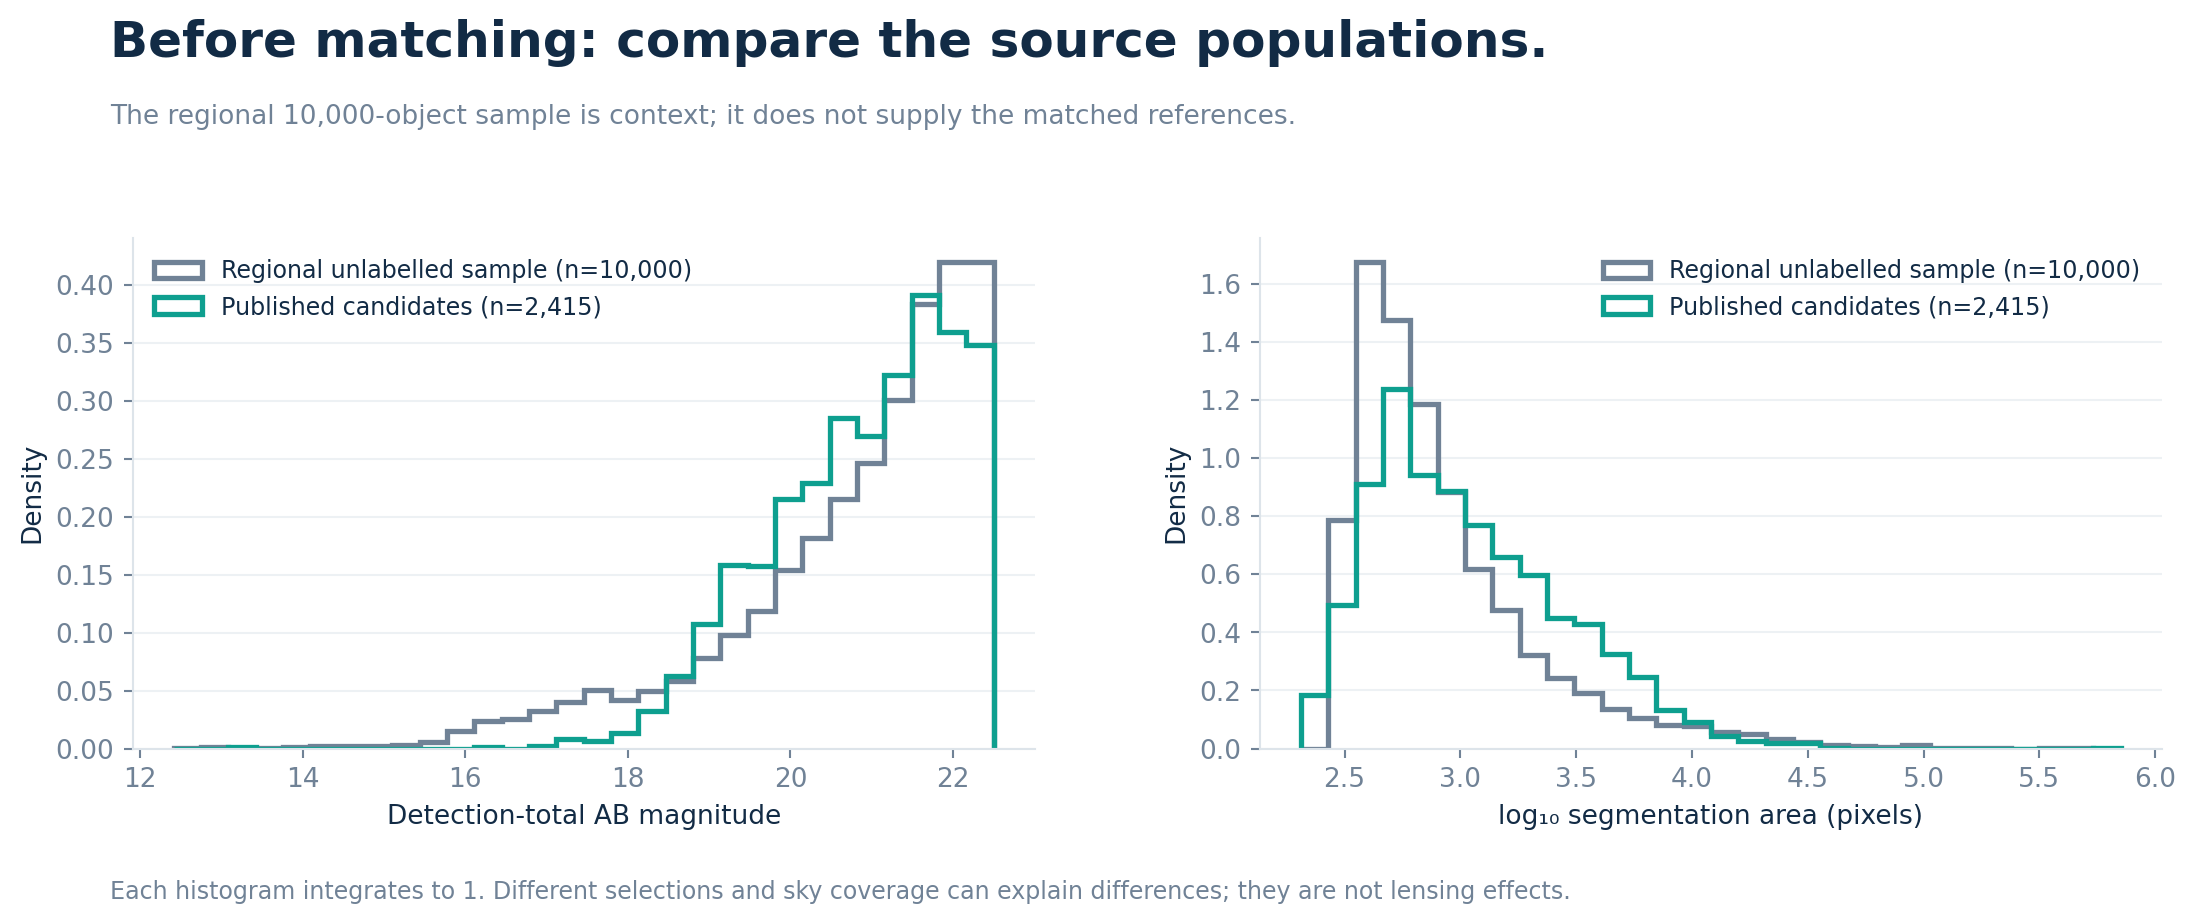

In [3]:
show(plots.plot_measurements(candidates, regional_sample, FIGURES), "eda_measurements.png")
# Retain the source audit in one machine-readable file; no extra report to read.
summary = plots.summarize(candidates, regional_sample, manifest=gallery)
summary["reference_sampling"] = sampling
(ROOT / "results/eda_summary.json").write_text(json.dumps(summary, indent=2) + "\n")

## 3 · Inspect real images

The gallery shows the first two objects per grade from the previously seeded six-per-grade selection. These are public VIS FITS cutouts, not simulations or new detections. Each image has its own contrast stretch, so grayscale intensity cannot be compared between panels. Scale bars come from the image WCS.

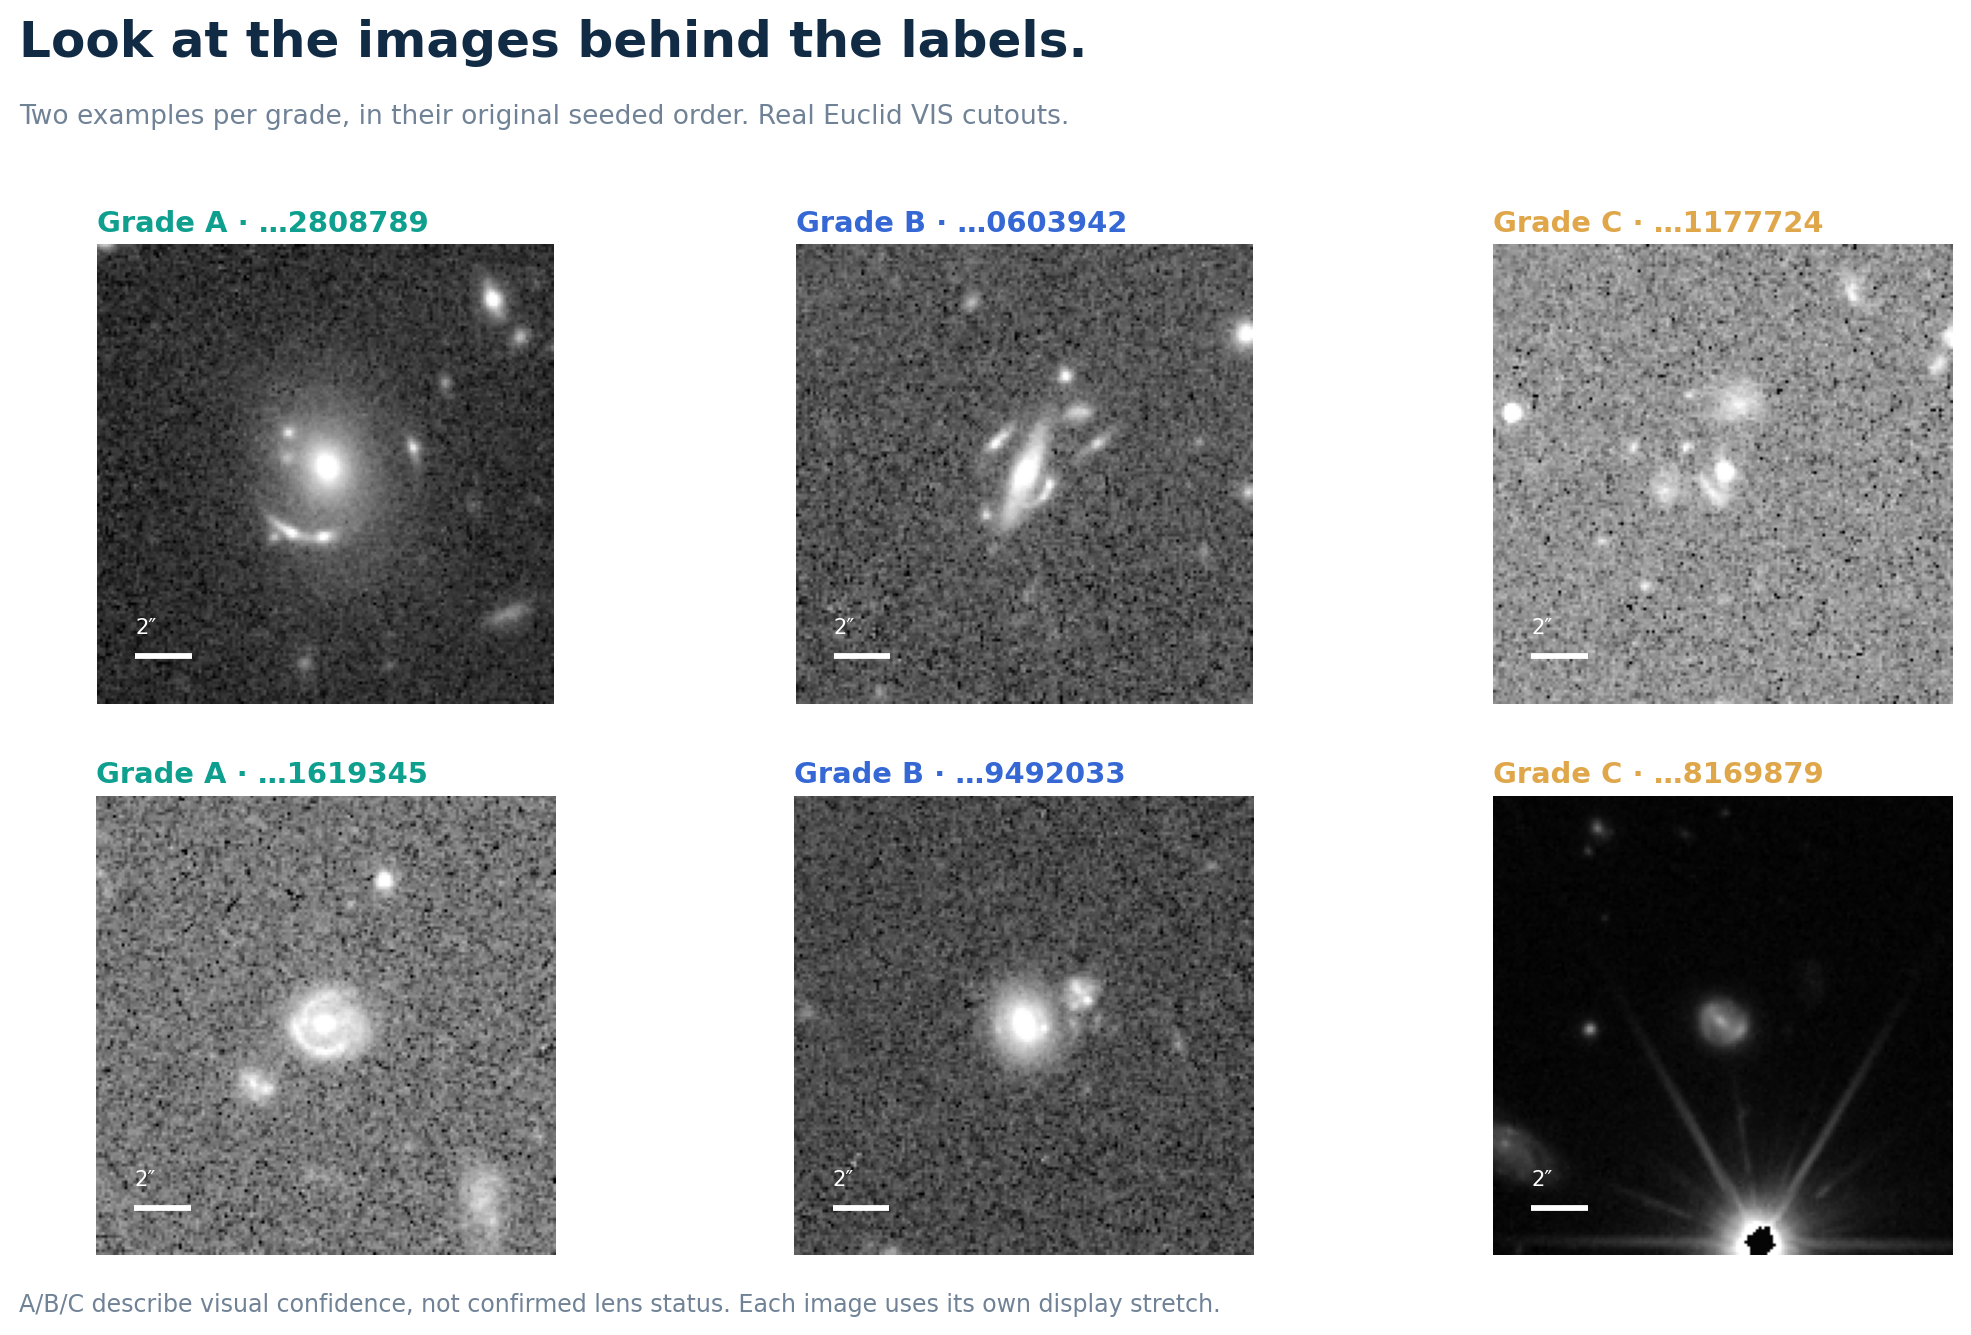

In [4]:
if gallery is None:
    raise FileNotFoundError("The gallery cache is missing; run python run.py --download.")
show(plots.plot_gallery(gallery, ROOT, FIGURES, n_per_grade=2), "eda_gallery.png")
plt.close(plots.plot_hero(gallery, ROOT, FIGURES))

## 4 · Give each candidate one comparable reference

We keep candidates with a published Zoobot vector that pass the common cuts. We then search the wider Q1 footprint around each eligible candidate, independently of the regional EDA sample.

An admissible reference must have **similar brightness** (magnitude difference ≤0.3), **similar apparent size** (log10 area difference ≤0.2), and be in the **same local sky neighbourhood** (within 108″). It must be outside the published candidate list and at least 20″ from every published candidate position.

A seeded allocation chooses one reference per candidate without reuse. The cost combines brightness, size and sky separation; it never uses the expert grade, image pixels or Zoobot coordinates. This is an observational comparison, not the choice of the most similar image according to Zoobot.

Retained candidates by grade: {'A': 112, 'B': 131, 'C': 883}
Frozen sample SHA256: 7e5b07c9d9ca992ec381713159154c7e652ac519e9761a882544a99044d45659


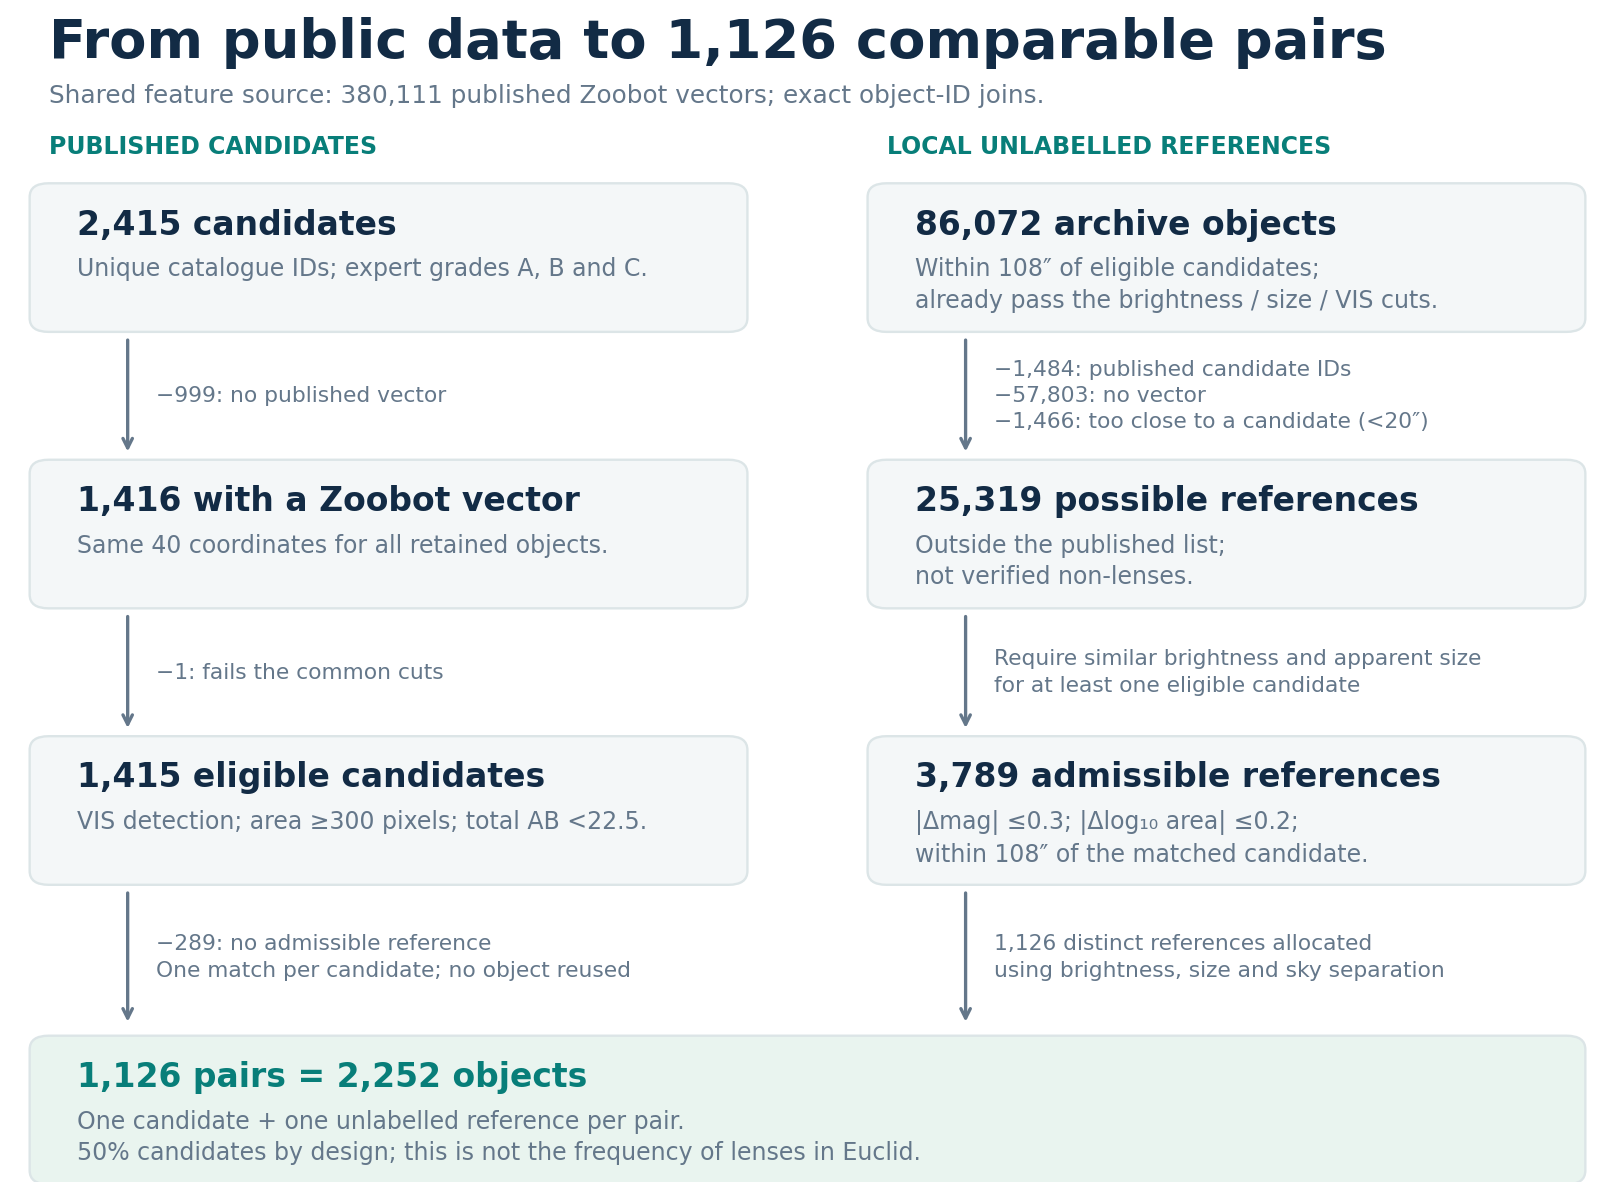

In [5]:
selection = selection_figures(ROOT)
pairs = pd.read_csv(ROOT / "data/processed/expanded_sample.csv", dtype={"object_id": str})
assert pairs.object_id.is_unique
assert pairs.groupby("set_id").size().eq(2).all()
assert pairs.groupby("set_id").role.nunique().eq(2).all()
display(Image(filename=str(FIGURES / "cohort_flow.png")))
print(f"Retained candidates by grade: {selection['by_grade']['retained']}")
print("Frozen sample SHA256:", selection["sample_sha256"])

## 5 · Check that the pairs are comparable

**1,126 candidates + 1,126 references = 2,252 objects.** One reference per candidate preserves broad candidate coverage under the unchanged matching criteria. Candidates without an admissible reference are excluded, rather than matched under looser criteria.

The brightness and size curves should be close after matching. Signal-to-noise was not part of the matching cost: it is an additional check. A standardized mean difference near zero indicates similar means, but does not guarantee identical populations. Sky proximity reduces some observing-condition differences; it cannot remove all spatial dependence or selection effects.

The 50% candidate proportion is a deliberate comparison design, not an estimate of how common lenses are in Euclid.

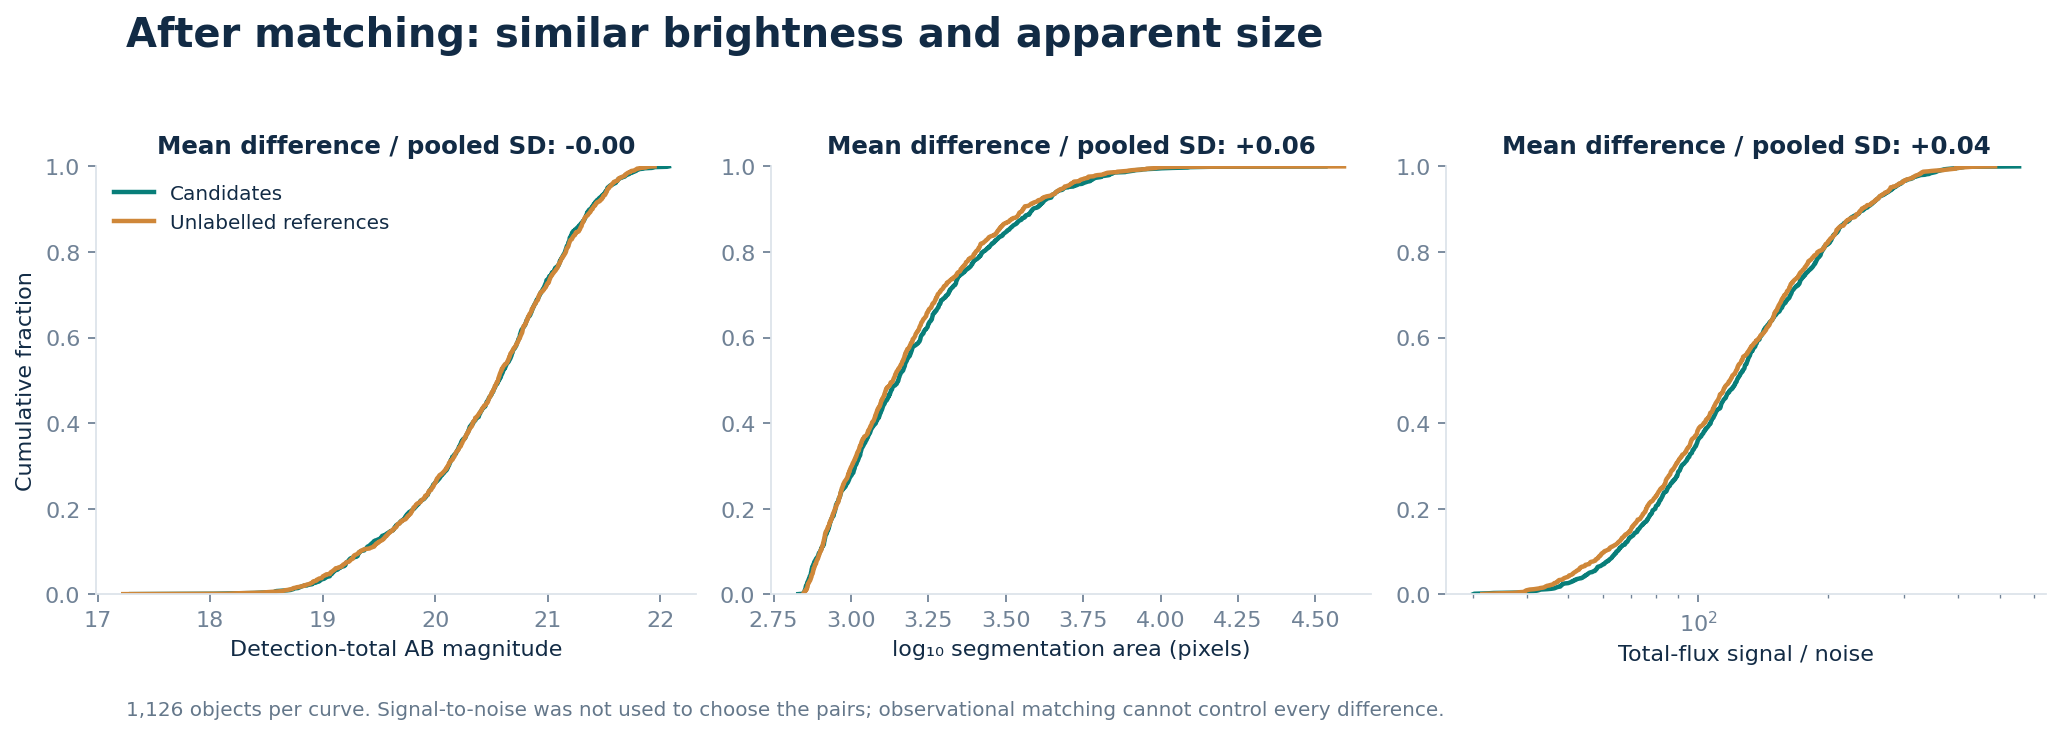

,Candidate median,Reference median,Mean difference / pooled SD
mag_total,20.567,20.558,-0.001
log_area,3.153,3.136,0.055
snr_total,122.932,118.469,0.044


In [6]:
display(Image(filename=str(FIGURES / "expanded_balance.png")))
display(pd.DataFrame(selection["balance"]).T.rename(columns={
    "candidate_median": "Candidate median",
    "reference_median": "Reference median",
    "standardized_mean_difference": "Mean difference / pooled SD",
}).round(3))

**Next:** `02_image_neighbours.ipynb` finds each object's ten nearest neighbours in the published Zoobot representation, excluding the object and its matched partner. Only then do we count candidate labels. The same notebook compares Zoobot with frozen DINOv2 on a fixed subset of the same pairs.

The matching controls obvious catalogue differences; it does not turn the references into confirmed non-lenses or remove prior candidate-selection effects.